# Práctica3

In [60]:
# Importando librearias necesarias:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Operator
from qiskit.circuit.library import UnitaryGate
from qiskit.visualization import plot_histogram
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np


## "Determina de qué tipo de función se trata"

Se ejecuta la siguiente línea que define oracledj(n)

In [79]:
exec(bytes.fromhex('0a696d706f72742072616e646f6d0a66726f6d207169736b697420696d706f7274205175616e74756d436972637569740a0a646566206f7261636c65646a286e293a0a20202020726573756c74203d205175616e74756d43697263756974286e2b31290a20202020726573756c742e6261727269657228290a0a2020202074797065203d2072616e646f6d2e63686f696365285b22636f6e7374616e74222c202262616c616e636564225d290a2020202069662074797065203d3d2022636f6e7374616e74223a0a202020202020202069662072616e646f6d2e72616e6472616e6765283229203d3d20303a0a202020202020202020202020726573756c742e78286e290a20202020656c73653a0a2020202020202020636f6e74726f6c203d2072616e646f6d2e72616e6472616e6765286e290a2020202020202020726573756c742e637828636f6e74726f6c2c206e290a202020202020202069662072616e646f6d2e72616e6472616e6765283229203d3d20303a0a202020202020202020202020726573756c742e78286e290a0a20202020726573756c742e6261727269657228290a2020202072657475726e20726573756c740a20202020').decode('utf-8'))

Guardamos nuestro oraculo, con n = 4

In [128]:
oraculo = oracledj(4)
op = Operator(oraculo)
matrix = op
Uf_Oracle = UnitaryGate(matrix, 'TheOracle') #Compuerta personalizada

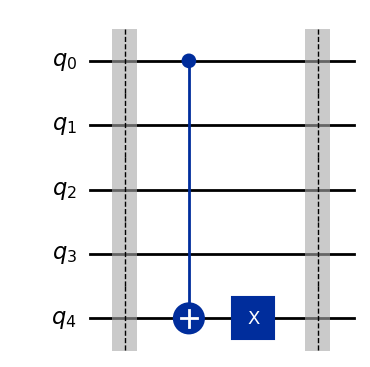

In [134]:
oraculo.draw('mpl')

Solo viendo la estructura de Uf podemos notar que si tenemos cualquier combinación donde q0 = 1 entonces q4 = 0, si no, entonces q4 = 1. Esto significa que para antes de 1000 (8 casos) se tiene 1 de salida, y a partir de 1000 hasta 1111 (8 casos) se tiene 0 de salida. Por lo que hay exactamente 8 ceros y 8 unos. Por lo que la función es balanceada. Pero hacer este análisis se complica mientras más compleja sea la función.

### Aplicando Deutsch – Jozsa

Creamos nuestro circuito con |10000>:

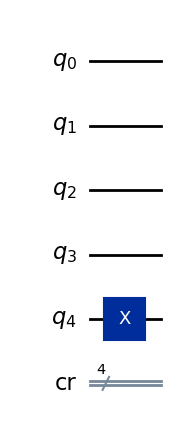

In [135]:
qc = QuantumRegister(5, name='q')# circuito con 5 qubits (4 de la función)
cr = ClassicalRegister(4, name='cr')         #4 bit clásicos
circuit= QuantumCircuit(qc, cr)
circuit.x(4) #X en bit q4

circuit.draw('mpl')


Aplicamos algoritmo:

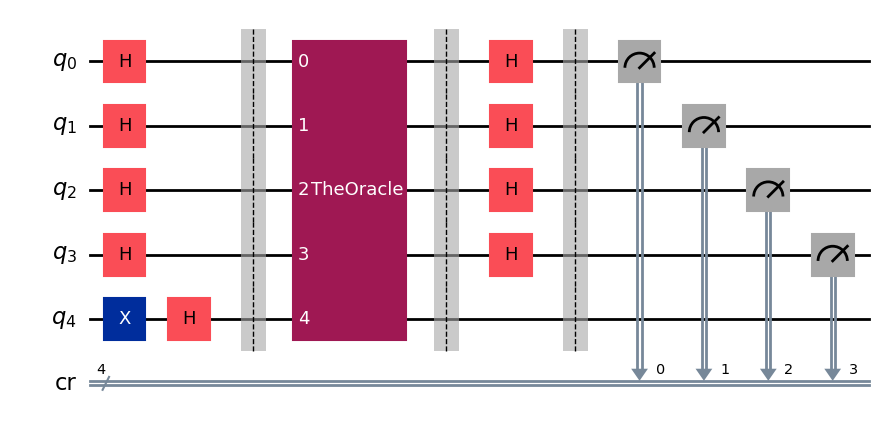

In [136]:
circuit.h(0) #H en q0
circuit.h(1) #H en q1
circuit.h(2) #H en q2
circuit.h(3) #H en q3
circuit.h(4) #H en q4

circuit.barrier()

circuit.append(Uf_Oracle, [0,1,2,3,4])

circuit.barrier()

circuit.h(0) #H en q0
circuit.h(1) #H en q1
circuit.h(2) #H en q2
circuit.h(3) #H en q3


circuit.barrier()

circuit.measure([0,1,2,3],[0,1,2,3])





circuit.draw('mpl')


Comprobamos mediante simulación resultado del algoritmo:

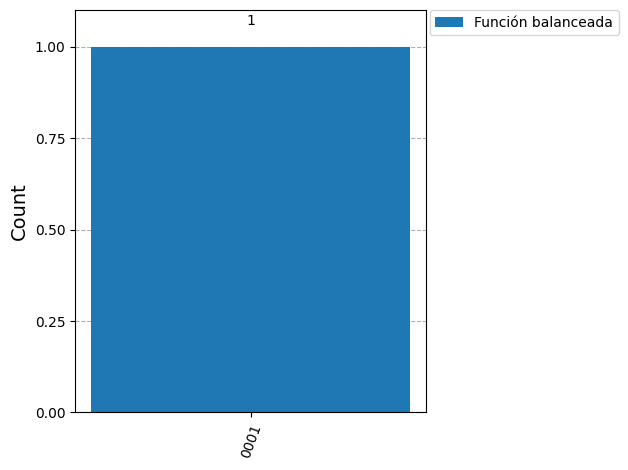

In [137]:
sim_basic = BasicSimulator()                       # usamos el simulador básico

# ejecutar el circuito, una sola vez es suficiente
job_sampler = sim_basic.run(circuit, shots=1)

conteos = job_sampler.result().get_counts()        # obtener los conteos

legend = ["Función balanceada"]
plot_histogram([conteos], legend=legend)

Da: $$|0001> \neq |0000>$$ por lo que la función es **balanceada**

## "Aplicar $H^{\otimes 4}$ a $\ket{15}$"

Tenemos la definición de la transformada de H Para cualquier caso de 0: $$ H^{\otimes n} \ket{0}^{\otimes n} = \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n-1} \ket{x} $$

Para los estados arbitrarios tenemos: $$
\begin{aligned}
H^{\otimes n} \ket{x} &= \frac{1}{\sqrt{2^n}} \sum_{z=0}^{2^n-1}(-1)^{x \cdot z} \ket{z}
\end{aligned}
$$

donde $\ket{x}=\ket{x_1\cdots x_n}$, $\ket{z}=\ket{z_1\cdots z_n}$ y $ x \cdot z $ es la operación producto punto (bit a bit) módulo 2, es decir,

$$ x \cdot z = \sum_{i=1}^n x_i \cdot z_i \pmod 2 $$

Como queremos calcular $\ket{15}$:

$\ket{15} = \ket{1111}$ y $n = 4$

Entonces:

\begin{aligned}
H^{\otimes 4} \ket{1111} &= \frac{1}{\sqrt{2^4}} \sum_{z=0}^{2^4-1}(-1)^{1111 \cdot z} \ket{z}
\end{aligned}




$$= \frac{1}{\sqrt{16}} \sum_{z=0}^{15}(-1)^{1111 \cdot z} \ket{z}$$

$$= \frac{1}{\sqrt{16}}[(-1)^{1111 \cdot 0000} + (-1)^{1111 \cdot 0001} + (-1)^{1111 \cdot 0010}+ (-1)^{1111 \cdot 0011} + (-1)^{1111 \cdot 0100} + (-1)^{1111 \cdot 0101} $$

$$+ (-1)^{1111 \cdot 00110} + (-1)^{1111 \cdot 0111} + (-1)^{1111 \cdot 1000} + (-1)^{1111 \cdot 1001} + (-1)^{1111 \cdot 1010} + (-1)^{1111 \cdot 1011} $$

$$+ (-1)^{1111 \cdot 1100} + (-1)^{1111 \cdot 1101} + (-1)^{1111 \cdot 1110} + (-1)^{1111 \cdot 1111})]\ket{z}$$

$$= \frac{1}{\sqrt{16}}[(-1)^{0}\ket{0000} + (-1)^{1}\ket{0001} + (-1)^{1}\ket{0010}+ (-1)^{0}\ket{0011} + (-1)^{1}\ket{0100} + (-1)^{0}\ket{0101}$$

$$ + (-1)^{0}\ket{0110} + (-1)^{1}\ket{0111} + (-1)^{1}\ket{1000} + (-1)^{0}\ket{1001} + (-1)^{0}\ket{1010} + (-1)^{1}\ket{1011}$$

$$ + (-1)^{0}\ket{1100} + (-1)^{1}\ket{1101} + (-1)^{1}\ket{1110} + (-1)^{0}\ket{1111}]$$

$$ = \frac{1}{4}[\ket{0000} - \ket{0001} - \ket{0010} + \ket{0011} - \ket{0100} + \ket{0101} + \ket{0110} - \ket{0111} - \ket{1000}$$

$$ + \ket{1001} + \ket{1010} - \ket{1011} + \ket{1100} - \ket{1101} - \ket{1110} + \ket{1111}]$$